In [108]:
import pandas as pd
import ast
import matplotlib.pyplot as plt


In [109]:
all_students = pd.read_csv('students.csv') 
all_students.head()

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt
0,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS83...",2025-03-31T17:16:08.460727,laura447@student.revoducate.edu,2023,9,958304305,Laura Taylor,252-622-2482x957,SCH800575,80.3,student,2025-03-31T17:16:08.486245
1,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,margaret92@student.revoducate.edu,2023,9,603796531,Margaret Escobar,(394)754-1197x292,SCH800575,71.8,student,2025-03-31T17:16:08.494096
2,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,raymond661@student.revoducate.edu,2020,12,995172986,Raymond Schultz,2548366373,SCH800575,78.7,student,2025-03-31T17:16:08.494096
3,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,christopher999@student.revoducate.edu,2023,9,853622281,Christopher Christensen,872-447-9460x3855,SCH800575,83.0,student,2025-03-31T17:16:08.494096
4,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,joshua675@student.revoducate.edu,2022,10,156379314,Joshua Johnston,651-509-7107x0979,SCH800575,68.4,student,2025-03-31T17:16:08.500244


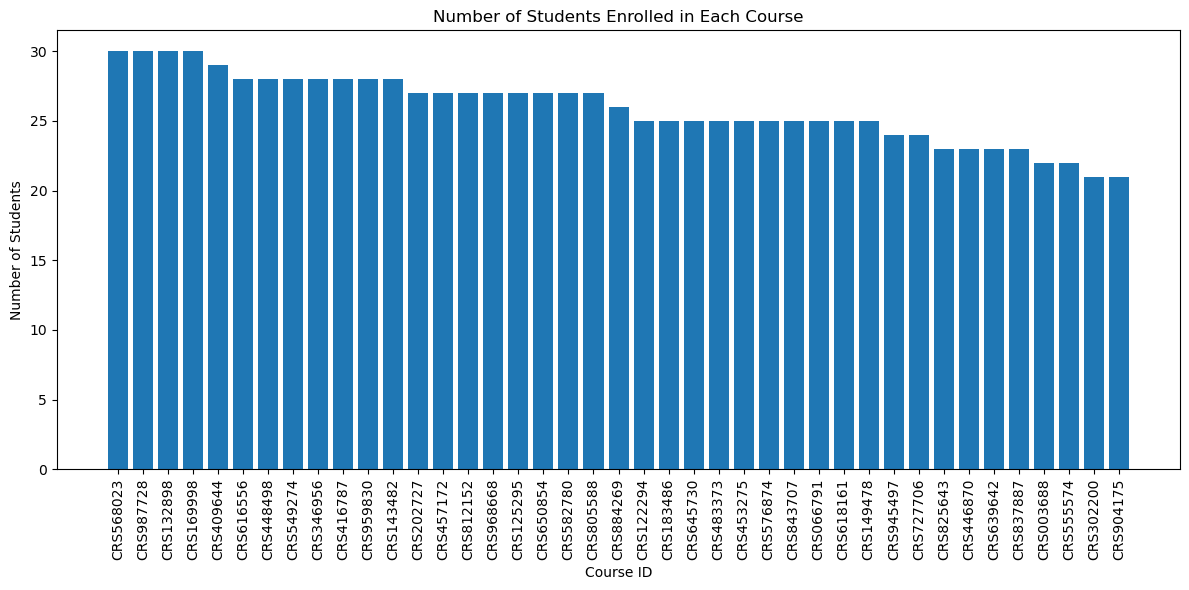

       Course  Student Count
0   CRS568023             30
1   CRS987728             30
2   CRS132898             30
3   CRS169998             30
4   CRS409644             29
5   CRS616556             28
6   CRS448498             28
7   CRS549274             28
8   CRS346956             28
9   CRS416787             28
10  CRS959830             28
11  CRS143482             28
12  CRS202727             27
13  CRS457172             27
14  CRS812152             27
15  CRS968668             27
16  CRS125295             27
17  CRS650854             27
18  CRS582780             27
19  CRS805588             27
20  CRS884269             26
21  CRS122294             25
22  CRS183486             25
23  CRS645730             25
24  CRS483373             25
25  CRS453275             25
26  CRS576874             25
27  CRS843707             25
28  CRS066791             25
29  CRS618161             25
30  CRS149478             25
31  CRS945497             24
32  CRS727706             24
33  CRS825643 

In [110]:

# Assuming all_students is your existing DataFrame
# Convert the string representation of courses to actual lists
all_students['parsed_courses'] = all_students['courses'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the DataFrame so each student-course pair gets its own row
student_courses = all_students.explode('parsed_courses')

# Count the number of students per course
course_counts = student_courses['parsed_courses'].value_counts().reset_index()
course_counts.columns = ['Course', 'Student Count']

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(course_counts['Course'], course_counts['Student Count'])
plt.xlabel('Course ID')
plt.ylabel('Number of Students')
plt.title('Number of Students Enrolled in Each Course')
plt.xticks(rotation=90)
plt.tight_layout()

# Display the plot
plt.show()

# Print the data for reference
print(course_counts)

In [111]:
all_courses = set()

# Parse the 'courses' column for each student
for course_str in all_students['courses']:
    try:
        # Parse the string representation of a list
        courses = ast.literal_eval(course_str)
        # Add each course to the set
        for course in courses:
            all_courses.add(course)
    except:
        # Skip rows with parsing issues
        continue

# Count the number of different courses
num_different_courses = len(all_courses)
print(f"Number of different courses: {num_different_courses}")
print("List of courses:", sorted(all_courses))

Number of different courses: 41
List of courses: ['CRS003688', 'CRS066791', 'CRS122294', 'CRS125295', 'CRS132898', 'CRS143482', 'CRS149478', 'CRS169998', 'CRS183486', 'CRS202727', 'CRS302200', 'CRS346956', 'CRS409644', 'CRS416787', 'CRS446870', 'CRS448498', 'CRS453275', 'CRS457172', 'CRS483373', 'CRS549274', 'CRS555574', 'CRS568023', 'CRS576874', 'CRS582780', 'CRS616556', 'CRS618161', 'CRS639642', 'CRS645730', 'CRS650854', 'CRS727706', 'CRS805588', 'CRS812152', 'CRS825643', 'CRS837887', 'CRS843707', 'CRS884269', 'CRS904175', 'CRS945497', 'CRS959830', 'CRS968668', 'CRS987728']


In [112]:
all_assignments = pd.read_csv('assignments.csv')

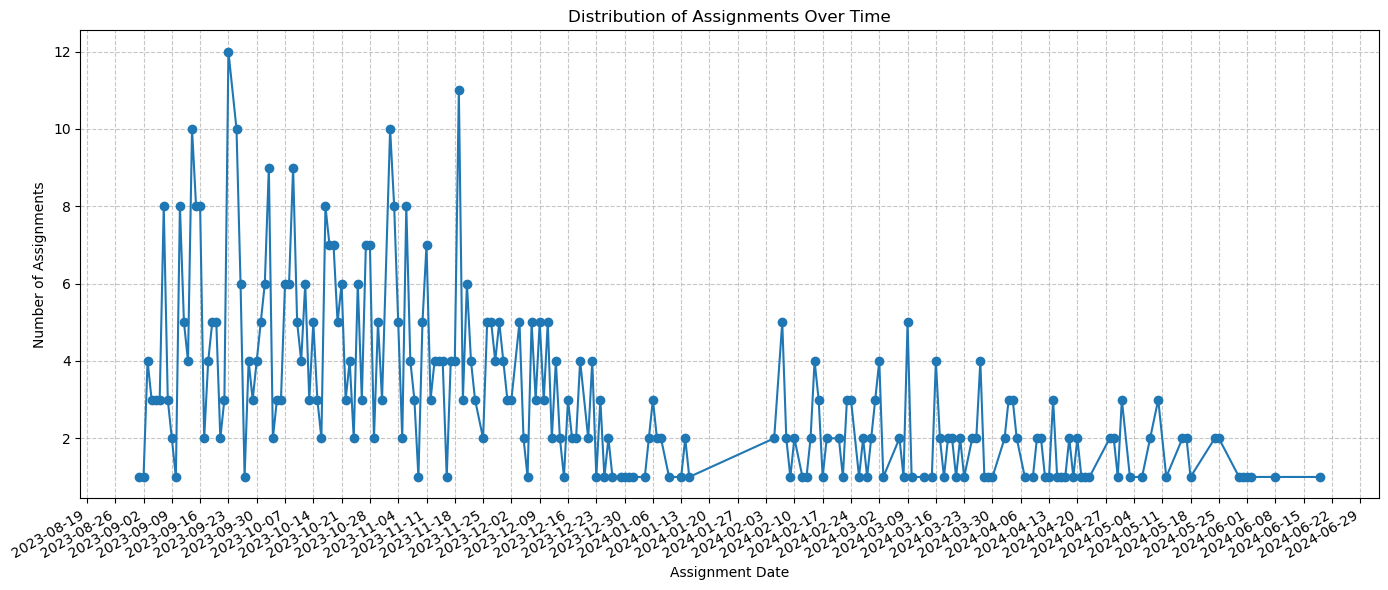

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Assuming all_assignments is your DataFrame with an 'assignDate' column

# Convert 'assignDate' to datetime if it's not already
all_assignments['assignDate'] = pd.to_datetime(all_assignments['assignDate'])

# Sort by date
all_assignments_sorted = all_assignments.sort_values('assignDate')

# Count assignments per date
assignments_by_date = all_assignments.groupby('assignDate').size().reset_index(name='count')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(assignments_by_date['assignDate'], assignments_by_date['count'], marker='o')

# Format the x-axis to show dates clearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Show tick every 7 days
plt.gcf().autofmt_xdate()  # Rotate date labels

# Add labels and title
plt.xlabel('Assignment Date')
plt.ylabel('Number of Assignments')
plt.title('Distribution of Assignments Over Time')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

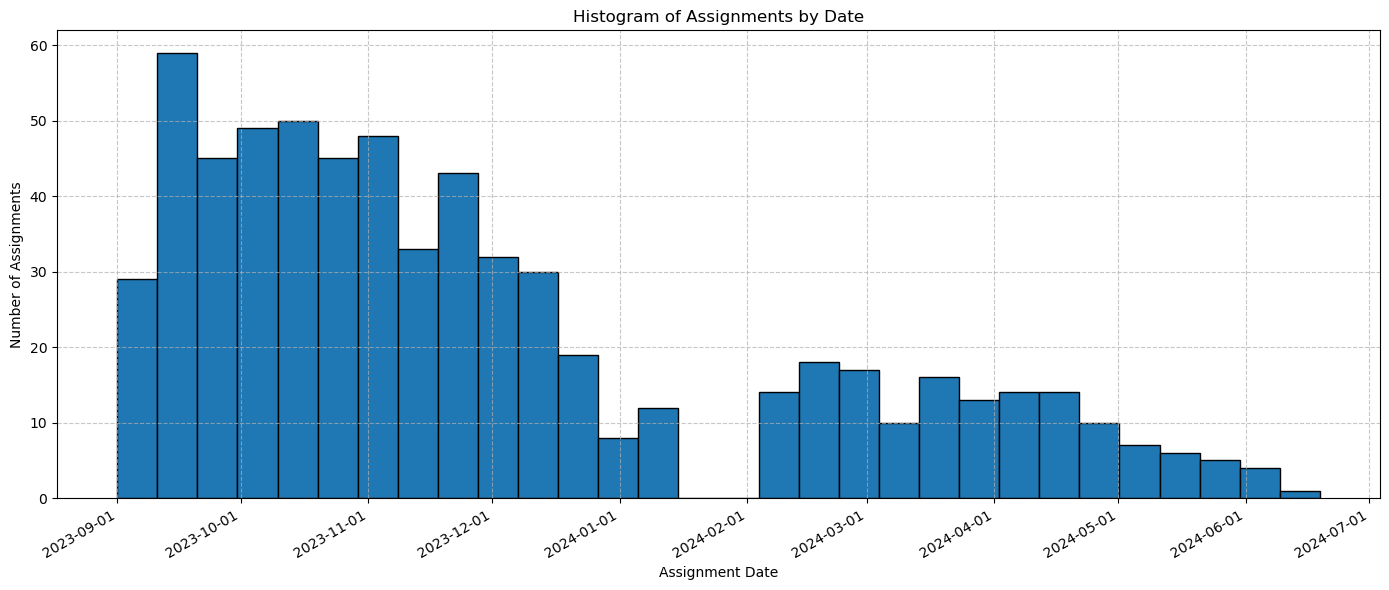

In [114]:
plt.figure(figsize=(14, 6))
plt.hist(all_assignments['assignDate'], bins=30, edgecolor='black')
plt.xlabel('Assignment Date')
plt.ylabel('Number of Assignments')
plt.title('Histogram of Assignments by Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [115]:
all_students = all_students[all_students['parsed_courses'].apply(len) > 0]
all_students

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt,parsed_courses
0,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS83...",2025-03-31T17:16:08.460727,laura447@student.revoducate.edu,2023,9,958304305,Laura Taylor,252-622-2482x957,SCH800575,80.3,student,2025-03-31T17:16:08.486245,"[CRS904175, CRS202727, CRS448498, CRS837887, C..."
1,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,margaret92@student.revoducate.edu,2023,9,603796531,Margaret Escobar,(394)754-1197x292,SCH800575,71.8,student,2025-03-31T17:16:08.494096,"[CRS904175, CRS202727, CRS448498, CRS549274, C..."
2,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,raymond661@student.revoducate.edu,2020,12,995172986,Raymond Schultz,2548366373,SCH800575,78.7,student,2025-03-31T17:16:08.494096,"[CRS904175, CRS202727, CRS448498, CRS549274, C..."
3,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,christopher999@student.revoducate.edu,2023,9,853622281,Christopher Christensen,872-447-9460x3855,SCH800575,83.0,student,2025-03-31T17:16:08.494096,"[CRS904175, CRS202727, CRS448498, CRS549274, C..."
4,"[""CRS904175"", ""CRS202727"", ""CRS448498"", ""CRS54...",2025-03-31T17:16:08.461726,joshua675@student.revoducate.edu,2022,10,156379314,Joshua Johnston,651-509-7107x0979,SCH800575,68.4,student,2025-03-31T17:16:08.500244,"[CRS904175, CRS202727, CRS448498, CRS549274, C..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,"[""CRS805588"", ""CRS555574"", ""CRS457172"", ""CRS81...",2025-03-31T17:16:08.473535,bryan643@student.אורטחקלאיפרדסחנה.edu,2021,11,184161783,Bryan Wang,922-449-6871,SCH622336,86.4,student,2025-03-31T17:16:09.149301,"[CRS805588, CRS555574, CRS457172, CRS812152, C..."
163,"[""CRS812152"", ""CRS805588"", ""CRS457172"", ""CRS45...",2025-03-31T17:16:08.474822,natasha218@student.אורטחקלאיפרדסחנה.edu,2023,9,213125044,Natasha Vazquez,001-943-802-3888x37187,SCH622336,55.7,student,2025-03-31T17:16:09.152300,"[CRS812152, CRS805588, CRS457172, CRS453275]"
164,"[""CRS812152"", ""CRS805588"", ""CRS457172""]",2025-03-31T17:16:08.475013,christopher837@student.אורטחקלאיפרדסחנה.edu,2022,10,327935864,Christopher Wells,(383)624-4874x11095,SCH622336,54.4,student,2025-03-31T17:16:09.153821,"[CRS812152, CRS805588, CRS457172]"
165,"[""CRS812152"", ""CRS805588"", ""CRS555574"", ""CRS45...",2025-03-31T17:16:08.474822,denise774@student.אורטחקלאיפרדסחנה.edu,2023,9,408269192,Denise Chan,851.991.4929x739,SCH622336,96.0,student,2025-03-31T17:16:09.158839,"[CRS812152, CRS805588, CRS555574, CRS457172, C..."


In [116]:
##students by grade
students_by_grade = all_students['totalScore'].value_counts().reset_index()
students_by_grade.columns = ['Grade', 'Student Count']
students_by_grade = students_by_grade.sort_values('Grade')
students_by_grade.to_csv('students_by_grade.csv', index=False)

In [117]:
studentwithzero = all_students[all_students['totalScore'] == 0]
studentwithzero

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt,parsed_courses


In [118]:
all_students = pd.read_csv('students.csv')

In [119]:
student_assignments = pd.read_csv('studentAssignments.csv')
student_assignments.head()

,assessmentScore,assignmentId,createdAt,id,isLate,studentId,submissionDate,timeSpentMinutes,updatedAt
0,86.2,ASG585656,2025-03-31T17:16:08.486245,sa_ddc9e83c,False,958304305,2023-09-08T00:00:00,61,2025-03-31T17:16:08.486245
1,90.3,ASG246988,2025-03-31T17:16:08.486245,sa_6572765b,False,958304305,2023-09-05T00:00:00,70,2025-03-31T17:16:08.486245
2,84.5,ASG894685,2025-03-31T17:16:08.486245,sa_ea4e8e6b,False,958304305,2023-09-14T00:00:00,52,2025-03-31T17:16:08.486245
3,85.3,ASG659033,2025-03-31T17:16:08.486245,sa_e04fed7f,False,958304305,2023-09-16T00:00:00,149,2025-03-31T17:16:08.486245
4,85.7,ASG971461,2025-03-31T17:16:08.486245,sa_4df64d3a,False,958304305,2023-09-20T00:00:00,117,2025-03-31T17:16:08.486245


In [120]:
## find student by id in student_assignments
student_id = 380215769
student_assignments[student_assignments['studentId'] == student_id]


,assessmentScore,assignmentId,createdAt,id,isLate,studentId,submissionDate,timeSpentMinutes,updatedAt


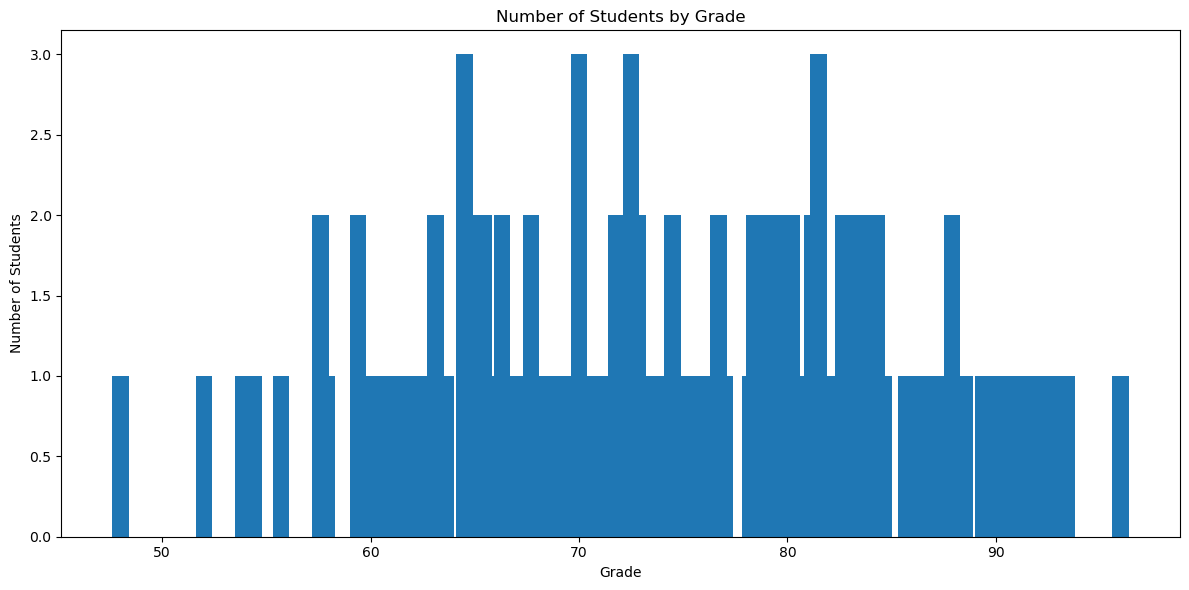

In [121]:
##plotting students by grade
plt.figure(figsize=(12, 6))
plt.bar(students_by_grade['Grade'], students_by_grade['Student Count'])
plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.title('Number of Students by Grade')
plt.tight_layout()
plt.show()


In [122]:
import pandas as pd
assignments = pd.read_csv('assignments.csv')
courses = pd.read_csv('courses.csv')
modules = pd.read_csv('modules.csv')
student_assignments = pd.read_csv('studentAssignments.csv')
student_courses = pd.read_csv('studentCourses.csv')
student = pd.read_csv('students.csv')
teachers = pd.read_csv('teachers.csv')
schools = pd.read_csv('schools.csv')
## name of table and columns 

table_names = {
    'assignments': assignments.columns.tolist(),
    'courses': courses.columns.tolist(),
    'modules': modules.columns.tolist(),
    'student_assignments': student_assignments.columns.tolist(),
    'student_courses': student_courses.columns.tolist(),
    'student': student.columns.tolist(),
    'teachers': teachers.columns.tolist(),
    'schools': schools.columns.tolist()
}
table_names
# save to txt file
with open('table_names.txt', 'w') as f:
    for table, columns in table_names.items():
        f.write(f"{table}:\n")
        f.write(", ".join(columns) + "\n\n")
        

In [123]:
import pandas as pd
import numpy as np

# Assuming students_df is your DataFrame

# Convert the 'courses' column to actual lists if they are strings
all_students['courses'] = all_students['courses'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# Filter out rows with empty lists in the 'courses' column
students_df = all_students[all_students['courses'].apply(lambda x: len(x) > 0)]

# Reset the index if needed
students_df = students_df.reset_index(drop=True)

# Display the cleaned DataFrame
print(students_df)

                                               courses  \
0    [CRS904175, CRS202727, CRS448498, CRS837887, C...   
1    [CRS904175, CRS202727, CRS448498, CRS549274, C...   
2    [CRS904175, CRS202727, CRS448498, CRS549274, C...   
3    [CRS904175, CRS202727, CRS448498, CRS549274, C...   
4    [CRS904175, CRS202727, CRS448498, CRS549274, C...   
..                                                 ...   
162  [CRS805588, CRS555574, CRS457172, CRS812152, C...   
163       [CRS812152, CRS805588, CRS457172, CRS453275]   
164                  [CRS812152, CRS805588, CRS457172]   
165  [CRS812152, CRS805588, CRS555574, CRS457172, C...   
166  [CRS812152, CRS805588, CRS639642, CRS555574, C...   

                      createdAt                                        email  \
0    2025-03-31T17:16:08.460727              laura447@student.revoducate.edu   
1    2025-03-31T17:16:08.461726            margaret92@student.revoducate.edu   
2    2025-03-31T17:16:08.461726            raymond661@student.r

In [124]:
# Count the number of students by entry year
students_by_entry_year = students_df['entryYear'].value_counts().reset_index()
students_by_entry_year.columns = ['Entry Year', 'Student Count']
students_by_entry_year = students_by_entry_year.sort_values('Entry Year')

# Display the data
print(students_by_entry_year)

# Save to a CSV file
students_by_entry_year.to_csv('students_by_entry_year.csv', index=False)

   Entry Year  Student Count
1        2020             44
2        2021             38
3        2022             37
0        2023             48


In [125]:
all_students.head()

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt
0,"[CRS904175, CRS202727, CRS448498, CRS837887, C...",2025-03-31T17:16:08.460727,laura447@student.revoducate.edu,2023,9,958304305,Laura Taylor,252-622-2482x957,SCH800575,80.3,student,2025-03-31T17:16:08.486245
1,"[CRS904175, CRS202727, CRS448498, CRS549274, C...",2025-03-31T17:16:08.461726,margaret92@student.revoducate.edu,2023,9,603796531,Margaret Escobar,(394)754-1197x292,SCH800575,71.8,student,2025-03-31T17:16:08.494096
2,"[CRS904175, CRS202727, CRS448498, CRS549274, C...",2025-03-31T17:16:08.461726,raymond661@student.revoducate.edu,2020,12,995172986,Raymond Schultz,2548366373,SCH800575,78.7,student,2025-03-31T17:16:08.494096
3,"[CRS904175, CRS202727, CRS448498, CRS549274, C...",2025-03-31T17:16:08.461726,christopher999@student.revoducate.edu,2023,9,853622281,Christopher Christensen,872-447-9460x3855,SCH800575,83.0,student,2025-03-31T17:16:08.494096
4,"[CRS904175, CRS202727, CRS448498, CRS549274, C...",2025-03-31T17:16:08.461726,joshua675@student.revoducate.edu,2022,10,156379314,Joshua Johnston,651-509-7107x0979,SCH800575,68.4,student,2025-03-31T17:16:08.500244
